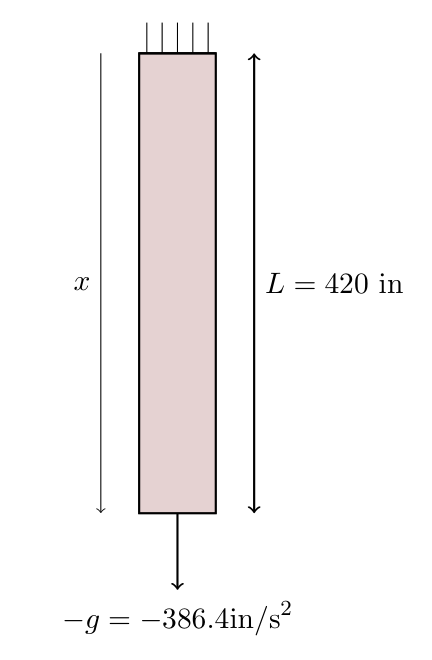

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.fom.fem_utils import load_domain
from skrom.utils.visualization.plot_utils import *
import skrom.problem_classes.static.master_class as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem
from skrom.utils.visualization.color_palette import set_color_palette
# SKROM ROM (Reduced Order Modeling) core classes
from skrom.rom.linear_form_rom import LinearFormROM
from skrom.rom.ecsw.hyperreduce import hyperreduce
from problem_def import ProblemNonLinear
# Problem-specific linear forms
from linear_forms import R

### Plot Properties


In [3]:
# # Define a custom color palette with 19 distinct colors
set_color_palette();

## Full Order Simulation


In [4]:
# Control flag for expensive simulation generation

generate = False

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots = 32)
    sim.run_simulation()


### Load Simulation Data

In [5]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from D:\OneDrive - Texas A&M University\SKROM\scikit-rom\examples\computational_mechanics\static\non_linear\problem_2_h\ROM_data


## Data Generation

### Generate Training Solution Dataset



In [6]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

64


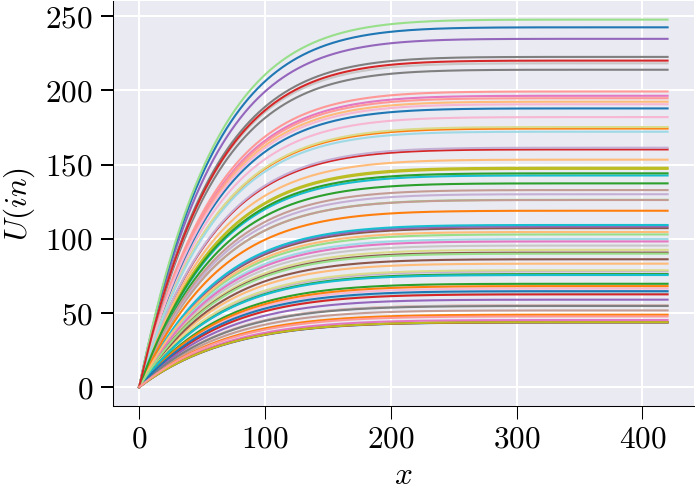

In [7]:
# Plot the computed temperature distribution
# Create a figure with specified dimensions (5x3.5 inches) for compact visualization
plt.figure(figsize=(5, 3.5))

# Extract spatial coordinates from the mesh data
# The mesh is stored as an object in sim_data, accessed via .item() to get the actual mesh
# mesh.p[0] contains the x-coordinates of the mesh nodes (1D spatial domain)
mesh_domain = sim_data['mesh'].item().p[0]

# Plot temperature profiles for all parameter combinations
# Loop through all non-linear solutions (each row is a complete temperature field)
for j in range(len(NLS)):
    # Plot each temperature distribution as a line
    # x-axis: spatial coordinates from the mesh
    # y-axis: temperature values at each spatial location
    # '-' specifies solid line style, markersize affects any markers
    plt.plot(mesh_domain, NLS[j], '-', markersize=2)

# Set axis labels with proper mathematical notation
plt.xlabel("$x$")        # Spatial coordinate (LaTeX formatting)
plt.ylabel("$U (in)$")    # Temperature in Kelvin (LaTeX formatting)

# Display the plot
plt.show()

### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

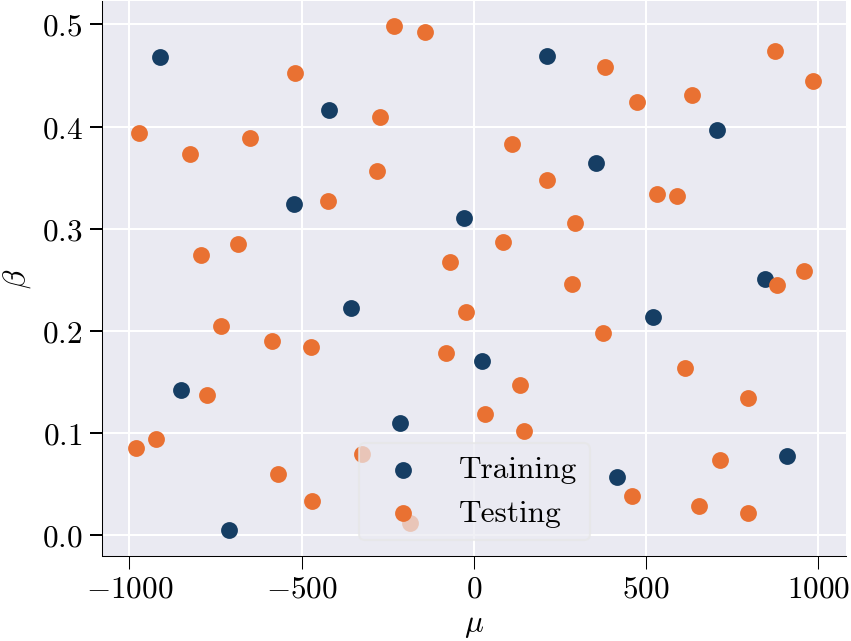

In [9]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on training snapshots

Number of modes selected: 4


Text(0.5, 0, 'POD modes ($k$)')

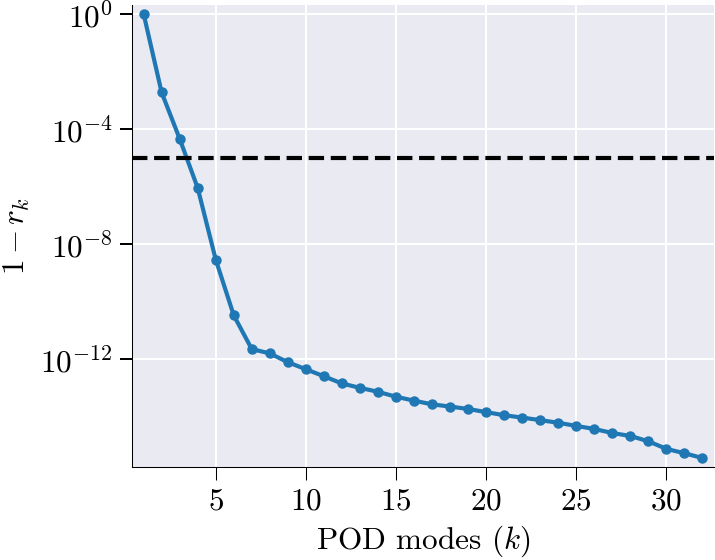

In [10]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-5,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors


# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation


In [11]:
# Initialize the reduced-order model (ROM) simulation
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
#   n_sel : number of basis vectors (modes) to retain in the ROM
rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel)

[load_rom_data] loaded from d:\OneDrive - Texas A&M University\SKROM\scikit-rom\examples\computational_mechanics\static\non_linear\problem_2_h\ROM_data


In [12]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
generate = True
if generate:
    rom.run_rom_simulation();
#Returns the Newton iteration errors just like full order simulation

Snap 1/64 params=[379.40464169   0.45840518]
[Newton] Iter  0, step norm = 8.523e+03
[Newton] Iter  1, step norm = 5.685e+03
[Newton] Iter  2, step norm = 3.331e+03
[Newton] Iter  3, step norm = 1.811e+03
[Newton] Iter  4, step norm = 9.454e+02
[Newton] Iter  5, step norm = 4.832e+02
[Newton] Iter  6, step norm = 2.443e+02
[Newton] Iter  7, step norm = 1.228e+02
[Newton] Iter  8, step norm = 6.158e+01
[Newton] Iter  9, step norm = 3.083e+01
[Newton] Iter 10, step norm = 1.543e+01
[Newton] Iter 11, step norm = 7.716e+00
[Newton] Iter 12, step norm = 3.859e+00
[Newton] Iter 13, step norm = 1.929e+00
[Newton] Iter 14, step norm = 9.647e-01
[Newton] Iter 15, step norm = 4.824e-01
[Newton] Iter 16, step norm = 2.412e-01
[Newton] Iter 17, step norm = 1.206e-01
[Newton] Iter 18, step norm = 6.030e-02
[Newton] Iter 19, step norm = 3.015e-02
[Newton] Iter 20, step norm = 1.507e-02
[Newton] Iter 21, step norm = 7.537e-03
Snap 2/64 params=[-5.69398211e+02  6.02409658e-02]
[Newton] Iter  0, step n

In [13]:
#Assign values for the statistics
NLS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 2.0776e-03
Relative L2 Error:        7.5152e-07
L∞ Error:                 2.7145e-04
Relative L∞ Error:        1.0960e-06
RMSE:                     9.1815e-05
MAE:                      7.4233e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -1.2571e-05
95th Percentile Error:    1.7189e-04

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 3.0137e-08
Max Rel L2 Error over time/parameter: 5.3813e-08
Min Rel L2 Error over time/parameter: 1.7700e-08
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

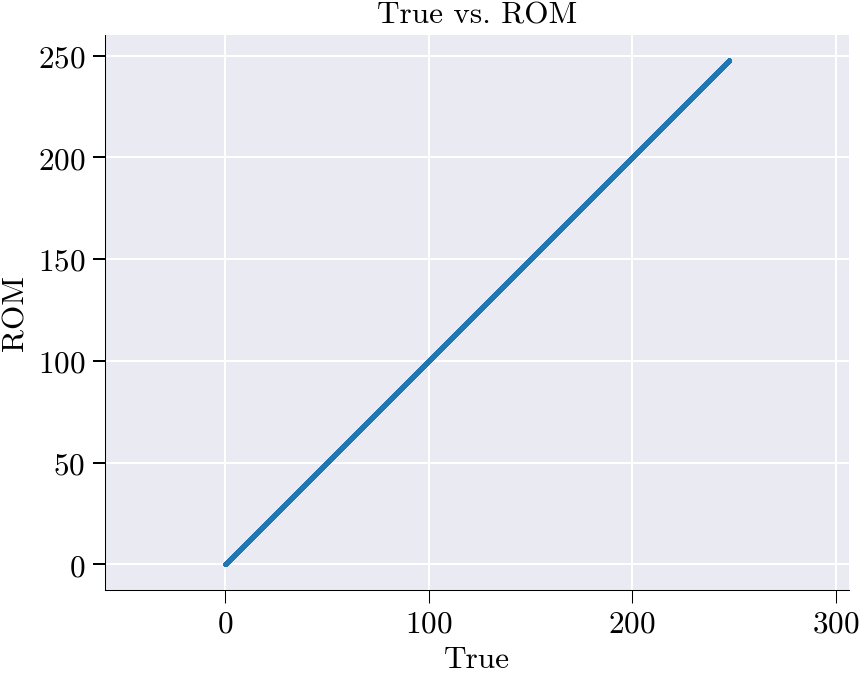

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


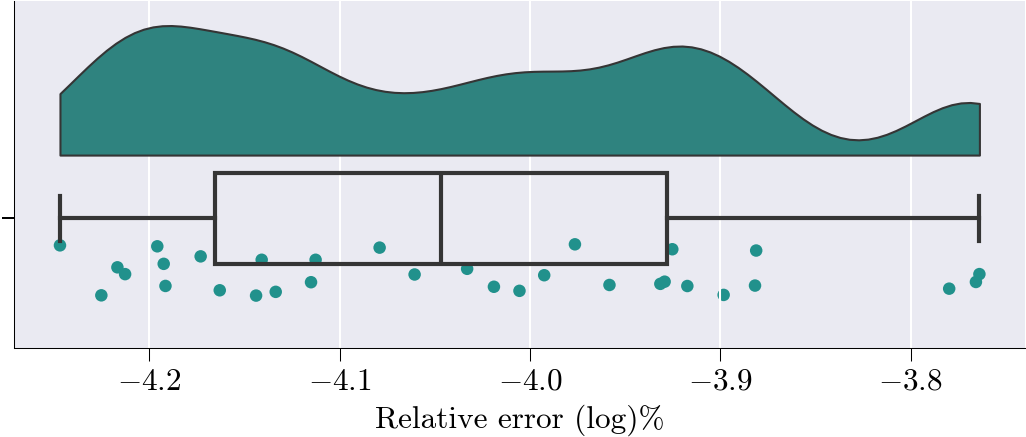

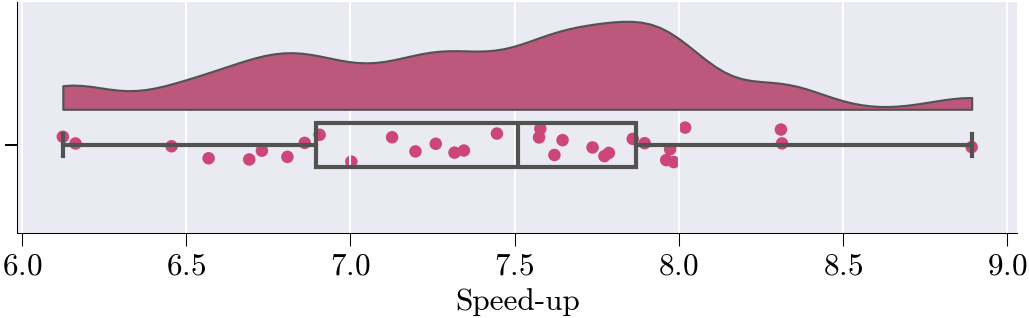

In [14]:
# --- Standard ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

# Produce a text-based report summarizing these error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the standard ROM
plot_rom_error_diagnostics_flat(
    NLS_test,               # full-order (true) solution snapshots
    NLS_rom,                # ROM-generated solution snapshots
    ROM_relative_error,     # precomputed relative error of the ROM
    ROM_speed_up,           # precomputed speed-up factor of the ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix          # the matrix of error metrics just computed
)


## Hyper ROM Simulation


### Mesh Sampling


In [15]:
prob = ProblemNonLinear()
sim_data['dirichlet_dofs'] = prob.domain()['dirichlet_boundary_dofs']
free_dofs = prob.domain()['free_dofs']

In [16]:
# Get the finite element basis object for ROM construction
# This contains the spatial discretization information and basis functions
basis = sim_data['basis'].item()

# Create the ROM residual linear form object
# This represents the linear form R(u,v) in the weak formulation of the PDE
Residual = LinearFormROM(R,                    # Linear form function from problem definition
                         basis,                 # Finite element basis functions
                         V_sel,                 # Selected POD modes (reduced basis)
                         free_dofs=free_dofs)   # Free DOFs (excluding Dirichlet boundaries)

# Extract parameter values corresponding to training snapshots
# Uses the boolean mask to get only the parameter combinations used for training
training_params = param_list[train_mask]

In [17]:
q_mus = collect_residuals(
    NLS_train_ms,
    NLS_train_mean,
    V_sel,
    reconstruct_solution,
    Residual,
    training_params,
    prob.assemble_kwargs,  
)
print(q_mus.shape)

(128, 16384)


#### Performing the SVD on snapshots

Performing SVD...
magnitude of d_q: 127.99709103628072


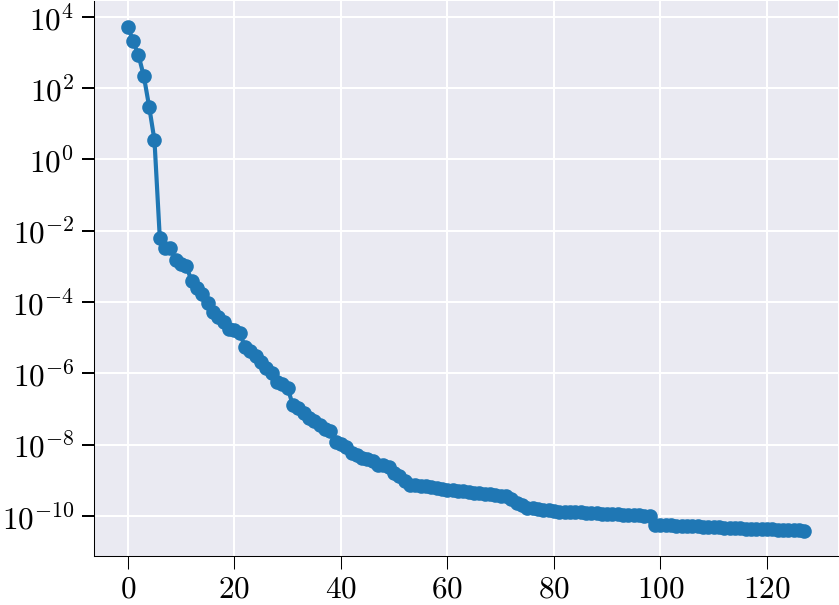

In [24]:
print("Performing SVD...")
# Performs Singular Value Decomposition on q_mus matrix
# Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

# Plots singular values on a logarithmic y-scale to visualize their decay
# This helps identify the effective rank/dimensionality of the matrix
plt.semilogy(s, 'o-')

# Takes the first 20 right singular vectors (rows of Vh)
# This creates a reduced basis capturing the most significant modes
V_q_eff = Vh[:100]

# Computes a weighted combination of the basis vectors
# Each basis vector is weighted equally (multiplied by 1)
# This essentially sums all 20 basis vectors
d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

# Outputs the L2 norm of the resulting vector
# This gives a sense of the magnitude of the combined basis representation
print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [25]:
# Solve the non-negative least squares (NNLS) problem using hyperreduce
#   V_q_eff   : effective basis matrix
#   verbosity : level of log output (2 = detailed)
#   const_tol : tolerance for column selection
#   zero_tol  : tolerance to treat values as zero
#   plot      : disable plotting
x_nnls_m, err = hyperreduce(
    V_q_eff,
    verbosity=2,
    const_tol=1e-8,
    zero_tol=1e-8,
    plot=False
)

# Compute and print the relative NNLS reconstruction error:
#   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
print("NNLS error:", rel_error)

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 100 16384 0 9.737829792257635e+01 1.279970910362807e+02
1 1 100 16384 1 9.300500490877992e+01 1.269947772995056e+02
2 2 100 16384 2 9.288704038607099e+01 1.269730491438674e+02
3 3 100 16384 3 9.277619316622699e+01 1.269099827615713e+02
4 4 100 16384 4 9.308536365024982e+01 1.268879932894801e+02
5 5 100 16384 5 9.304672688489980e+01 1.268768244597235e+02
6 6 100 16384 6 9.218508654204300e+01 1.266974016634164e+02
7 7 100 16384 7 9.238859064247455e+01 1.266797410113806e+02
8 8 100 16384 8 9.241923713233723e+01 1.266465603833820e+02
9 9 100 16384 9 9.235336459786959e+01 1.266284031035784e+02
10 10 100 16384 10 9.216303317043246e+01 1.264838750477566e+02
11 11 100 16384 11 9.211616455083136e+01 1.264692003743783e+02
12 12 100 16384 12 9.199231421291073e+01 1.264338469834697e+02
13 13 100 16384 13 9.188992784144847e+01 1.264027446492052e+02
14 15 100 16384 13 9.152748814859446e+01 1.255109028143918e+02
15 17 100 16384 13 9.164

#### Plot Reduced Meshes with weights

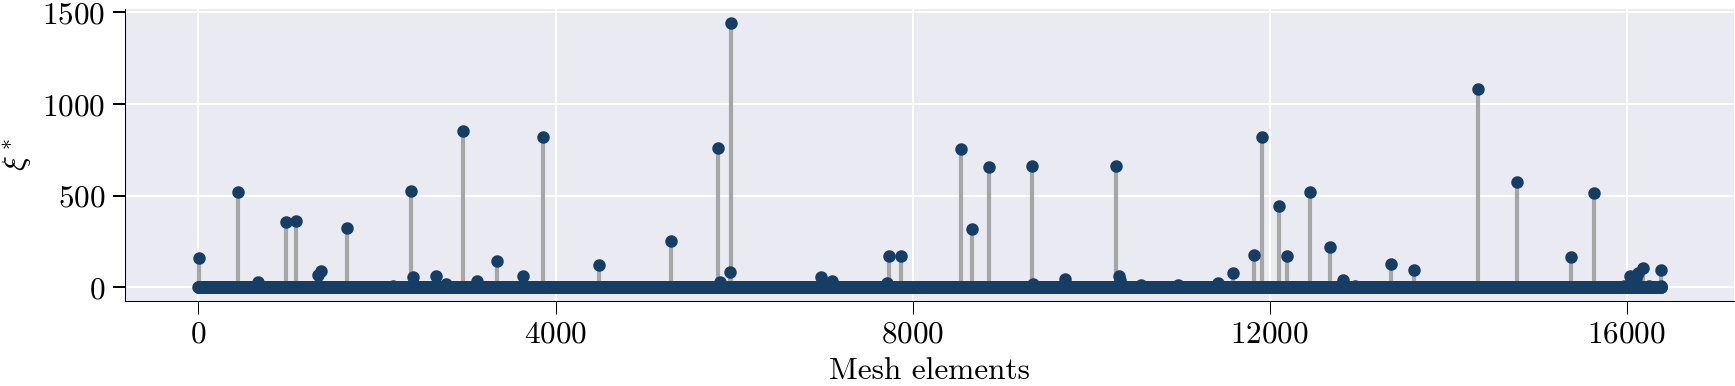

In [26]:
fig, ax = plot_ecsw_weights(x_nnls_m)

### Run HyperROM simulation


In [27]:
# Run the hyper-reduced ROM simulation using the NNLS weights
#   x_nnls_m : array of non-negative least squares coefficients,
#              used here to weight the reduced basis contributions
# rom will contain the hyper_rom solution as an attribute

rom.run_hyper_rom_simulation_ecsw(x_nnls_m)

Snap 1/64 params=[379.40464169   0.45840518]
[Newton] Iter  0, step norm = 8.541e+03
[Newton] Iter  1, step norm = 2.052e+03
[Newton] Iter  2, step norm = 7.049e+01
[Newton] Iter  3, step norm = 7.652e-02
[Newton] Iter  4, step norm = 1.012e-07
Snap 2/64 params=[-5.69398211e+02  6.02409658e-02]
[Newton] Iter  0, step norm = 5.203e+03
[Newton] Iter  1, step norm = 8.260e+02
[Newton] Iter  2, step norm = 4.926e+01
[Newton] Iter  3, step norm = 1.569e-01
[Newton] Iter  4, step norm = 1.790e-06
Snap 3/64 params=[-4.22111435e+02  3.27294988e-01]
[Newton] Iter  0, step norm = 6.238e+03
[Newton] Iter  1, step norm = 6.012e+02
[Newton] Iter  2, step norm = 8.315e+00
[Newton] Iter  3, step norm = 1.575e-03
[Newton] Iter  4, step norm = 1.049e-08
Snap 4/64 params=[6.12972487e+02 1.63946371e-01]
[Newton] Iter  0, step norm = 9.119e+03
[Newton] Iter  1, step norm = 1.582e+03
[Newton] Iter  2, step norm = 1.341e+02
[Newton] Iter  3, step norm = 8.059e-01
[Newton] Iter  4, step norm = 3.201e-05
Snap

([0.002826670616113401,
  0.004175765556497795,
  0.0031635687751309398,
  0.0037151177001953327,
  0.003375527195890448,
  0.003508774124059286,
  0.002984193873718347,
  0.0039010630818957057,
  0.0031050668082975024,
  0.003822809643309891,
  0.0027379965950007604,
  0.004374771442813508,
  0.002890632551830551,
  0.004082425103274171,
  0.003290215341320119,
  0.0035839279599045562,
  0.003227174126387339,
  0.003559435427418646,
  0.0029436282373726482,
  0.004109870338634422,
  0.0027924306446152386,
  0.004432581303606986,
  0.003035369015673401,
  0.003783656163807024,
  0.003011649440357344,
  0.004023723725963427,
  0.003344291137675202,
  0.0034207977477038244,
  0.0031450268189854333,
  0.003634263056597664,
  0.002839386272975001,
  0.00430455801202771],
 [86.94599181373832,
  101.25612038356886,
  114.83753434128705,
  87.79710447751324,
  100.9585526822332,
  114.38731315884462,
  115.8585903843889,
  153.41296782697555,
  114.38339367189757,
  113.85332065989608,
  95.7

In [28]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error = rom.hyper_rom_error

### Hyper ROM vs Full order solution performance statistics


ROM Accuracy Report

Global Errors:
L2 Error:                 8.5580e-02
Relative L2 Error:        3.0956e-05
L∞ Error:                 7.0378e-03
Relative L∞ Error:        2.8416e-05
RMSE:                     3.7820e-03
MAE:                      3.4023e-03

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0001

Error Distribution:
Median Error:             -3.2527e-03
95th Percentile Error:    6.2318e-03

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 1.0854e-06
Max Rel L2 Error over time/parameter: 1.3852e-06
Min Rel L2 Error over time/parameter: 8.5562e-07
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

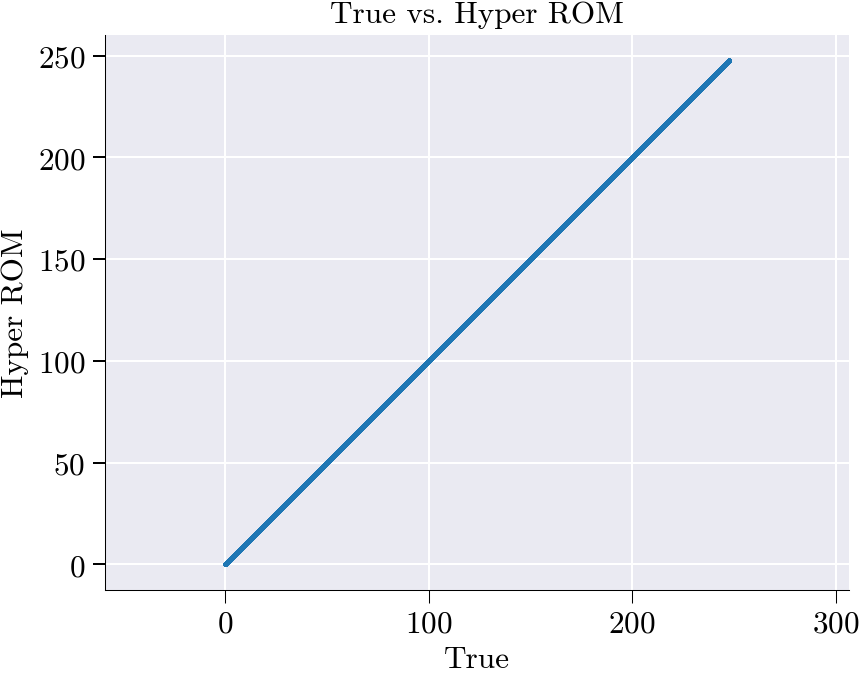

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


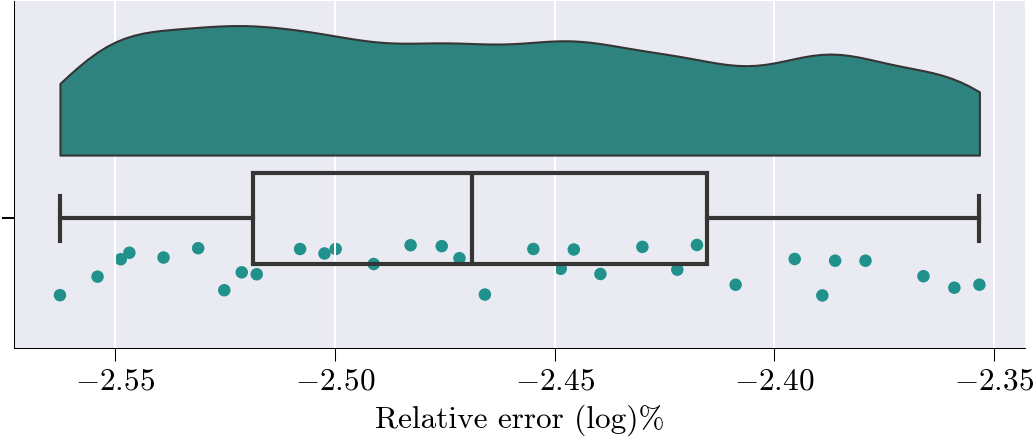

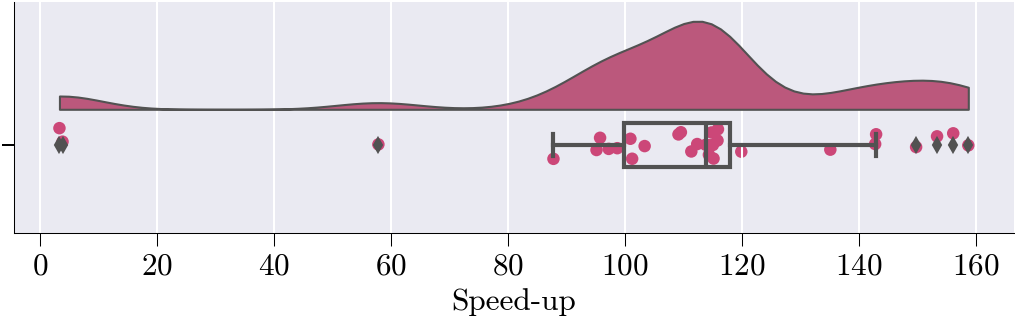

In [29]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)

